# NB10 — Skenario D: UMAP + HDBSCAN + LOF + KNN Label Propagation

**Tujuan:** menguji apakah pipeline clustering yang dioptimasi (LOF → UMAP → HDBSCAN → KNN)
menghasilkan metrik lebih baik dibanding Skenario A (HDBSCAN langsung di ruang 512-dim).

**Pipeline:**
```
ArcFace 512-dim
  ↓ LOF (n_neighbors=20, contamination=0.03)
    Bersihkan outlier di embedding space sebelum kompresi UMAP
  ↓ UMAP (512 → 30-dim, metric=cosine, min_dist=0.0)
    Reduksi dimensi agar densitas HDBSCAN lebih terbaca
  ↓ HDBSCAN (mcs=25, ms=5)
    Cluster natural; sisa noise adalah wajah berdensitas rendah
  ↓ KNN Propagation (k=5, cosine)
    Selesaikan noise HDBSCAN → coverage naik
```

**Input:** `output_nb01/embeddings.npy`, `output_nb05/metadata_labeled.pkl`

**Output:** `output_nb10/skenario_d_results.pkl`, `output_nb10/lof_outlier_indices.npy`

**Catatan:** LOF outlier (3%) tetap berlabel -1 setelah KNN — tidak dipaksakan masuk cluster.
Hanya noise HDBSCAN (wajah jarang difoto) yang dipropagasikan.

In [1]:
# Cell 1 — Install & Imports
# umap-learn belum tentu tersedia di Colab default — install sekali
!pip install umap-learn -q

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from collections import Counter
from sklearn.neighbors import LocalOutlierFactor, KNeighborsClassifier
from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                              silhouette_score, davies_bouldin_score)
import umap
import hdbscan

from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


In [2]:
# Cell 2 — Config (ubah di sini sebelum run)
BASE      = Path("/content/drive/MyDrive/OTW S.KOM/Embeddings")
NB01_DIR  = BASE / "output_nb01"
NB05_DIR  = BASE / "output_nb05"
OUTPUT_DIR = BASE / "output_nb10"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── LOF ──────────────────────────────────────────────────────────────
# contamination=0.03 → ~457 wajah dari 15.248 di-flag outlier
# Validasi jumlah ini dengan NB09 face gallery (berapa false-positive deteksi?)
LOF_N_NEIGHBORS   = 20
LOF_CONTAMINATION = 0.03

# ── UMAP ─────────────────────────────────────────────────────────────
# min_dist=0.0 untuk clustering (padat), bukan visualisasi (0.1-0.5)
# metric=cosine tepat untuk L2-normalized ArcFace embeddings
UMAP_N_COMPONENTS  = 30
UMAP_N_NEIGHBORS   = 15
UMAP_MIN_DIST      = 0.0
UMAP_METRIC        = 'cosine'
UMAP_RANDOM_STATE  = 42   # wajib untuk reproducibility

# ── HDBSCAN ──────────────────────────────────────────────────────────
# mcs lebih kecil dari Skenario A (50) karena di ruang 30-dim densitas
# lebih tinggi — cluster kecil lebih mudah terbentuk
HDBSCAN_MCS = 25
HDBSCAN_MS  = 5

# ── KNN Propagation ──────────────────────────────────────────────────
# KNN_DIST_THRESHOLD: None = propagasikan semua noise HDBSCAN
#                     float (mis. 0.5) = hanya jika dekat cluster
KNN_K              = 5
KNN_DIST_THRESHOLD = None

print('Config OK.')
print(f'Output: {OUTPUT_DIR}')

Config OK.
Output: /content/drive/MyDrive/OTW S.KOM/Embeddings/output_nb10


In [3]:
# Cell 3 — Load Data
embeddings = np.load(NB01_DIR / "embeddings.npy").astype(np.float32)
with open(NB05_DIR / "metadata_labeled.pkl", "rb") as f:
    meta = pickle.load(f)
N = len(meta)
assert len(embeddings) == N, f"Mismatch: {len(embeddings)} emb vs {N} meta"

# Ground-truth identity (dari labeling) & cluster Skenario A (baseline)
identity_ids = np.array([m.get("identity_id", -1) for m in meta])
labels_A     = np.array([m["cluster_id"] for m in meta])

n_gt      = (identity_ids >= 0).sum()
n_noise_A = (labels_A == -1).sum()
print(f"Total wajah     : {N:,}")
print(f"Dimensi emb.    : {embeddings.shape[1]}")
print(f"Ada ground-truth: {n_gt:,} ({n_gt/N*100:.1f}%)")
print(f"Noise Skenario A: {n_noise_A:,} ({n_noise_A/N*100:.1f}%)")
print(f"Cluster di A    : {labels_A.max()+1 if labels_A.max()>=0 else 0}")

Total wajah     : 15,248
Dimensi emb.    : 512
Ada ground-truth: 0 (0.0%)
Noise Skenario A: 3,871 (25.4%)
Cluster di A    : 72


LOF outlier detection...
  n_neighbors=20, contamination=0.03

Hasil LOF:
  Inlier  : 14,790 (97.0%)
  Outlier : 458 (3.0%)
  → Simpan outlier_indices ke Drive untuk verifikasi di NB09


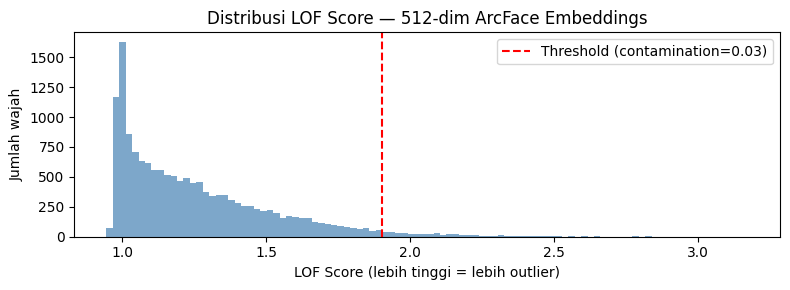

In [4]:
# Cell 4 — LOF Outlier Detection (di ruang 512-dim)
# LOF beroperasi di embedding space (cosine distance), BERBEDA dari FQA
# yang beroperasi di pixel space. Keduanya komplementer, bukan duplikasi.
print("LOF outlier detection...")
print(f"  n_neighbors={LOF_N_NEIGHBORS}, contamination={LOF_CONTAMINATION}")

lof = LocalOutlierFactor(
    n_neighbors=LOF_N_NEIGHBORS,
    contamination=LOF_CONTAMINATION,
    metric='cosine',
    n_jobs=-1
)
is_inlier   = lof.fit_predict(embeddings)        # 1=inlier, -1=outlier
lof_scores  = -lof.negative_outlier_factor_      # tinggi = lebih outlier

n_outlier   = (is_inlier == -1).sum()
n_inlier    = (is_inlier == 1).sum()
idx_inlier  = np.where(is_inlier == 1)[0]
idx_outlier = np.where(is_inlier == -1)[0]

print(f"\nHasil LOF:")
print(f"  Inlier  : {n_inlier:,} ({n_inlier/N*100:.1f}%)")
print(f"  Outlier : {n_outlier:,} ({n_outlier/N*100:.1f}%)")
print(f"  → Simpan outlier_indices ke Drive untuk verifikasi di NB09")

np.save(OUTPUT_DIR / "lof_outlier_indices.npy", idx_outlier)

# Distribusi LOF score
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(lof_scores, bins=100, color='steelblue', alpha=0.7)
threshold_score = np.percentile(lof_scores, 100 * (1 - LOF_CONTAMINATION))
ax.axvline(threshold_score, color='red', linestyle='--',
           label=f'Threshold (contamination={LOF_CONTAMINATION})')
ax.set_xlabel('LOF Score (lebih tinggi = lebih outlier)')
ax.set_ylabel('Jumlah wajah')
ax.set_title('Distribusi LOF Score — 512-dim ArcFace Embeddings')
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
# Cell 5 — UMAP: 512 → 30 dim (hanya pada inlier)
# Outlier LOF di-eksklusi dari UMAP agar tidak mendistorsi manifold
print(f"UMAP {embeddings.shape[1]}→{UMAP_N_COMPONENTS} dim...")
print(f"  n_neighbors={UMAP_N_NEIGHBORS}, min_dist={UMAP_MIN_DIST}")
print(f"  metric={UMAP_METRIC}, random_state={UMAP_RANDOM_STATE}")
print(f"  Input: {n_inlier:,} wajah inlier")

emb_inlier = embeddings[idx_inlier]

reducer = umap.UMAP(
    n_components=UMAP_N_COMPONENTS,
    n_neighbors=UMAP_N_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    metric=UMAP_METRIC,
    random_state=UMAP_RANDOM_STATE,
    verbose=True
)
X_umap = reducer.fit_transform(emb_inlier)
print(f"\nUMAP selesai. Shape: {X_umap.shape}")

# Simpan reducer — dipakai di Cell 8 untuk transform noise points
joblib.dump(reducer, OUTPUT_DIR / "umap_reducer.pkl")
np.save(OUTPUT_DIR / "umap_coords_inlier.npy", X_umap)
print("Reducer & coords disimpan.")

UMAP 512→30 dim...
  n_neighbors=15, min_dist=0.0
  metric=cosine, random_state=42
  Input: 14,790 wajah inlier
UMAP(angular_rp_forest=True, metric='cosine', min_dist=0.0, n_components=30, n_jobs=1, random_state=42, verbose=True)
Sun Jul  5 15:06:00 2026 Construct fuzzy simplicial set
Sun Jul  5 15:06:00 2026 Finding Nearest Neighbors
Sun Jul  5 15:06:00 2026 Building RP forest with 11 trees


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Sun Jul  5 15:06:03 2026 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	 3  /  14
	 4  /  14
	Stopping threshold met -- exiting after 4 iterations
Sun Jul  5 15:06:18 2026 Finished Nearest Neighbor Search
Sun Jul  5 15:06:24 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Sun Jul  5 15:07:01 2026 Finished embedding

UMAP selesai. Shape: (14790, 30)
Sun Jul  5 15:07:01 2026 Building hub-based search tree
Sun Jul  5 15:07:11 2026 Forward diversification reduced edges from 221850 to 63828
Sun Jul  5 15:07:15 2026 Reverse diversification reduced edges from 63828 to 63828
Sun Jul  5 15:07:17 2026 Degree pruning reduced edges from 68514 to 68514
Sun Jul  5 15:07:17 2026 Resorting data and graph based on tree order
Sun Jul  5 15:07:17 2026 Building and compiling search function
Reducer & coords disimpan.


In [6]:
# Cell 6 — HDBSCAN di ruang UMAP 30-dim
# mcs=25 (lebih kecil dari A=50) karena di ruang rendah dimensi,
# densitas lokal lebih padat → cluster kecil lebih mudah terbentuk
print(f"HDBSCAN mcs={HDBSCAN_MCS}, ms={HDBSCAN_MS}...")

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=HDBSCAN_MCS,
    min_samples=HDBSCAN_MS,
    metric='euclidean',        # Euclidean tepat di UMAP space
    cluster_selection_method='eom',
    prediction_data=True
)
labels_inlier = clusterer.fit_predict(X_umap)

n_clusters  = len(set(labels_inlier)) - (1 if -1 in labels_inlier else 0)
n_noise_hdb = (labels_inlier == -1).sum()
n_clust_hdb = (labels_inlier >= 0).sum()
print(f"\nHasil HDBSCAN:")
print(f"  Jumlah cluster : {n_clusters}")
print(f"  Ter-cluster    : {n_clust_hdb:,} ({n_clust_hdb/n_inlier*100:.1f}% dari inlier)")
print(f"  Noise HDBSCAN  : {n_noise_hdb:,} ({n_noise_hdb/n_inlier*100:.1f}% dari inlier)")

# Distribusi ukuran cluster
sizes = sorted(Counter(labels_inlier[labels_inlier >= 0].tolist()).values(), reverse=True)
print(f"  Cluster terbesar  : {sizes[0] if sizes else 0} wajah")
print(f"  Cluster terkecil  : {sizes[-1] if sizes else 0} wajah")
print(f"  Median ukuran     : {int(np.median(sizes)) if sizes else 0} wajah")

HDBSCAN mcs=25, ms=5...

Hasil HDBSCAN:
  Jumlah cluster : 105
  Ter-cluster    : 14,272 (96.5% dari inlier)
  Noise HDBSCAN  : 518 (3.5% dari inlier)
  Cluster terbesar  : 1949 wajah
  Cluster terkecil  : 27 wajah
  Median ukuran     : 88 wajah


In [7]:
# Cell 7 — Susun labels_D sebelum KNN propagation
# Inisialisasi: semua wajah noise (-1)
# LOF outlier → tetap -1 (permanen, tidak akan dipropagasikan)
# Inlier ter-cluster HDBSCAN → label cluster
# Inlier noise HDBSCAN → -1 (kandidat KNN propagation di Cell 8)

labels_D_pre_knn = np.full(N, -1, dtype=int)
labels_D_pre_knn[idx_inlier] = labels_inlier

# Kategorisasi noise
mask_lof_outlier = is_inlier == -1
mask_hdb_noise   = (labels_D_pre_knn == -1) & (~mask_lof_outlier)  # inlier tapi noise HDBSCAN
mask_clustered   = labels_D_pre_knn >= 0

print("Status sebelum KNN propagation:")
print(f"  Ter-cluster (HDBSCAN)  : {mask_clustered.sum():,} ({mask_clustered.sum()/N*100:.1f}%)")
print(f"  Noise HDBSCAN (inlier) : {mask_hdb_noise.sum():,} ({mask_hdb_noise.sum()/N*100:.1f}%)"
      " ← akan dipropagasikan KNN")
print(f"  LOF outlier (permanen) : {mask_lof_outlier.sum():,} ({mask_lof_outlier.sum()/N*100:.1f}%)"
      " ← tidak dipropagasikan")
print(f"  Coverage saat ini      : {mask_clustered.sum()/N*100:.1f}%")

Status sebelum KNN propagation:
  Ter-cluster (HDBSCAN)  : 14,272 (93.6%)
  Noise HDBSCAN (inlier) : 518 (3.4%) ← akan dipropagasikan KNN
  LOF outlier (permanen) : 458 (3.0%) ← tidak dipropagasikan
  Coverage saat ini      : 93.6%


In [8]:
# Cell 8 — KNN Label Propagation untuk noise HDBSCAN
# Logika: LOF outlier = 'embedding sangat berbeda' → jangan paksa masuk cluster
#         HDBSCAN noise = 'neighborhood kurang padat' → bisa punya identitas,
#         hanya orang jarang difoto. KNN mencarikan cluster terdekat.
print(f"KNN propagation: k={KNN_K}")
print(f"  Noise HDBSCAN yang akan dipropagasikan: {mask_hdb_noise.sum():,}")

# Train KNN hanya pada wajah ter-cluster (di UMAP space)
X_train = X_umap[labels_inlier >= 0]           # UMAP coords inlier ter-cluster
y_train = labels_inlier[labels_inlier >= 0]    # label cluster-nya

knn = KNeighborsClassifier(n_neighbors=KNN_K, metric='euclidean', algorithm='auto')
knn.fit(X_train, y_train)

# Proyeksikan noise HDBSCAN ke UMAP space (transform, bukan fit_transform)
emb_hdb_noise  = embeddings[mask_hdb_noise]
X_umap_noise   = reducer.transform(emb_hdb_noise)

labels_D = labels_D_pre_knn.copy()
idx_hdb_noise = np.where(mask_hdb_noise)[0]

if KNN_DIST_THRESHOLD is not None:
    dists, _ = knn.kneighbors(X_umap_noise)
    close_mask = dists[:, 0] < KNN_DIST_THRESHOLD
    labels_D[idx_hdb_noise[close_mask]] = knn.predict(X_umap_noise[close_mask])
    print(f"  Dipropagasikan (dist < {KNN_DIST_THRESHOLD}): {close_mask.sum():,}")
    print(f"  Tetap noise (terlalu jauh) : {(~close_mask).sum():,}")
else:
    labels_D[idx_hdb_noise] = knn.predict(X_umap_noise)
    print("  Semua noise HDBSCAN dipropagasikan (KNN_DIST_THRESHOLD=None)")

n_final_clustered = (labels_D >= 0).sum()
n_final_noise     = (labels_D == -1).sum()
print(f"\nSetelah KNN propagation:")
print(f"  Ter-cluster  : {n_final_clustered:,} ({n_final_clustered/N*100:.1f}%)")
print(f"  Noise final  : {n_final_noise:,} ({n_final_noise/N*100:.1f}%) — hanya LOF outlier")

KNN propagation: k=5
  Noise HDBSCAN yang akan dipropagasikan: 518


Epochs completed:   0%|            0/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs
  Semua noise HDBSCAN dipropagasikan (KNN_DIST_THRESHOLD=None)

Setelah KNN propagation:
  Ter-cluster  : 14,790 (97.0%)
  Noise final  : 458 (3.0%) — hanya LOF outlier


In [9]:
# Cell 9 — Evaluasi & Perbandingan Skenario A vs D

# ── Metrik Internal (DBCV, Silhouette, DBI) ────────────────────────
# Dihitung di UMAP 30-dim space, SEBELUM KNN propagation.
# TIDAK bisa dibandingkan langsung dengan Skenario A karena ruang berbeda
# (A: 512-dim cosine; D: 30-dim Euclidean). Dilaporkan terpisah.

# DBCV — metrik primer HDBSCAN (Moulavi et al., 2014)
# Range: -1 (buruk) → 1 (sempurna). Menghitung density-connectedness.
# Pakai labels_inlier (pre-KNN) karena DBCV mengukur struktur densitas,
# bukan label hasil propagasi.
dbcv_D = hdbscan.validity_index(X_umap.astype(np.float64), labels_inlier)
print(f"DBCV Skenario D (pre-KNN) : {dbcv_D:.4f}")

# Silhouette & DBI — hanya pada wajah ter-cluster (noise HDBSCAN di-exclude)
mask_clust_inlier = labels_inlier >= 0
if mask_clust_inlier.sum() > 1 and len(set(labels_inlier[mask_clust_inlier])) > 1:
    sil_D = silhouette_score(X_umap[mask_clust_inlier],
                             labels_inlier[mask_clust_inlier],
                             metric='euclidean')
    dbi_D = davies_bouldin_score(X_umap[mask_clust_inlier],
                                 labels_inlier[mask_clust_inlier])
else:
    sil_D = dbi_D = float('nan')
print(f"Silhouette D (UMAP space) : {sil_D:.4f}")
print(f"DBI        D (UMAP space) : {dbi_D:.4f}  (lebih kecil = lebih baik)")
print()

# ── Metrik Eksternal (ARI, NMI, Purity, Coverage) ───────────────────
# Dihitung terhadap ground-truth identity_id — bisa dibandingkan A vs D.
mask_eval = identity_ids >= 0
if mask_eval.sum() == 0:
    print("PERINGATAN: Tidak ada wajah dengan identity_id >= 0.")
    print("Pastikan metadata_labeled.pkl memiliki kolom identity_id.")
else:
    gt     = identity_ids[mask_eval]
    pred_D = labels_D[mask_eval]
    pred_A = labels_A[mask_eval]

    def purity_score(y_true, y_pred):
        clusters = {}
        for t, p in zip(y_true, y_pred):
            clusters.setdefault(p, []).append(t)
        correct = sum(Counter(v).most_common(1)[0][1] for v in clusters.values())
        return correct / len(y_true)

    ari_D    = adjusted_rand_score(gt, pred_D)
    ari_A    = adjusted_rand_score(gt, pred_A)
    nmi_D    = normalized_mutual_info_score(gt, pred_D, average_method='arithmetic')
    nmi_A    = normalized_mutual_info_score(gt, pred_A, average_method='arithmetic')
    purity_D = purity_score(gt, pred_D)
    purity_A = purity_score(gt, pred_A)

    coverage_A  = (labels_A >= 0).sum() / N
    coverage_D  = n_final_clustered / N
    n_cluster_A = labels_A.max() + 1 if labels_A.max() >= 0 else 0
    n_cluster_D = len(set(labels_D[labels_D >= 0]))

    SEP = '=' * 62
    print(SEP)
    print(f"{'Metrik':<32} {'Skenario A':>13} {'Skenario D':>13}")
    print(SEP)
    # Internal — D only (space tidak sama, A tidak ditampilkan)
    print(f"{'DBCV (primer, UMAP space)*':<32} {'—':>13} {dbcv_D:>13.4f}")
    print(f"{'Silhouette (UMAP space)*':<32} {'—':>13} {sil_D:>13.4f}")
    print(f"{'DBI (UMAP space)*':<32} {'—':>13} {dbi_D:>13.4f}")
    print(f"{'  * tidak dapat dibandingkan dengan A':}")
    print('-' * 62)
    # External — A vs D
    print(f"{'ARI':<32} {ari_A:>13.4f} {ari_D:>13.4f}")
    print(f"{'NMI':<32} {nmi_A:>13.4f} {nmi_D:>13.4f}")
    print(f"{'Purity':<32} {purity_A:>13.4f} {purity_D:>13.4f}")
    print(f"{'Coverage':<32} {coverage_A:>13.1%} {coverage_D:>13.1%}")
    print(f"{'Noise rate':<32} {1-coverage_A:>13.1%} {1-coverage_D:>13.1%}")
    print(f"{'Jumlah cluster':<32} {n_cluster_A:>13} {n_cluster_D:>13}")
    print(SEP)
    print(f"\nKomponen LOF/UMAP/HDBSCAN/KNN:")
    print(f"  LOF outlier (permanen noise): {n_outlier:,} ({n_outlier/N*100:.1f}%)")
    print(f"  Noise HDBSCAN pre-KNN       : {mask_hdb_noise.sum():,}")
    print(f"  KNN propagated              : {n_final_clustered - mask_clustered.sum():,}")

DBCV Skenario D (pre-KNN) : 0.7634
Silhouette D (UMAP space) : 0.8336
DBI        D (UMAP space) : 0.4440  (lebih kecil = lebih baik)

PERINGATAN: Tidak ada wajah dengan identity_id >= 0.
Pastikan metadata_labeled.pkl memiliki kolom identity_id.


In [10]:
# Cell 10 — Simpan Hasil
results_D = {
    "labels_D"           : labels_D,
    "labels_D_pre_knn"   : labels_D_pre_knn,
    "lof_is_inlier"      : is_inlier,
    "lof_scores"         : lof_scores,
    "umap_coords_inlier" : X_umap,
    "idx_inlier"         : idx_inlier,
    "idx_outlier"        : idx_outlier,
    "params": {
        "lof_n_neighbors"   : LOF_N_NEIGHBORS,
        "lof_contamination" : LOF_CONTAMINATION,
        "umap_n_components" : UMAP_N_COMPONENTS,
        "umap_n_neighbors"  : UMAP_N_NEIGHBORS,
        "umap_min_dist"     : UMAP_MIN_DIST,
        "hdbscan_mcs"       : HDBSCAN_MCS,
        "hdbscan_ms"        : HDBSCAN_MS,
        "knn_k"             : KNN_K,
        "knn_dist_threshold": KNN_DIST_THRESHOLD,
    },
}

# Tambahkan metrik jika evaluasi berhasil dijalankan
if mask_eval.sum() > 0:
    results_D["metrics"] = {
        "ari_D"     : ari_D,
        "nmi_D"     : nmi_D,
        "purity_D" : purity_D,
        "coverage_D": coverage_D,
        "ari_A"     : ari_A,
        "nmi_A"     : nmi_A,
        "purity_A" : purity_A,
        "coverage_A": coverage_A,
    }

with open(OUTPUT_DIR / "skenario_d_results.pkl", "wb") as f:
    pickle.dump(results_D, f)
np.save(OUTPUT_DIR / "labels_D.npy", labels_D)

print("Hasil disimpan ke output_nb10/:")
print("  skenario_d_results.pkl")
print("  labels_D.npy")
print("  lof_outlier_indices.npy  (dari Cell 4)")
print("  umap_coords_inlier.npy   (dari Cell 5)")
print("  umap_reducer.pkl          (dari Cell 5)")

Hasil disimpan ke output_nb10/:
  skenario_d_results.pkl
  labels_D.npy
  lof_outlier_indices.npy  (dari Cell 4)
  umap_coords_inlier.npy   (dari Cell 5)
  umap_reducer.pkl          (dari Cell 5)
